<a href="https://colab.research.google.com/github/Dinithiii04/AgriLak/blob/yield-model-experiments/notebooks/NEW_classification_rf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paddy Yield Forecasting - Data Pre-processing & Model Implementation




## Preprocessing Yield Dataset

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [119]:
# Load the dataset
file_path = '/content/drive/MyDrive/NEW_yield_data.csv'

maha_yield = pd.read_csv(file_path)

In [120]:
# Display the first few rows to verify
display(maha_yield.head(10))


,District,Year,Yield,Cultivation_Season
0,PUTTALAM,1984,2158,1983-1984
1,MONARAGALA,1984,3074,1983-1984
2,JAFFNA,1984,1255,1983-1984
3,VAVUNIYA,1984,1992,1983-1984
4,MULLATIVU,1984,1153,1983-1984
5,MANNAR,1984,3644,1983-1984
6,ANURADHAPURA,1984,3144,1983-1984
7,POLONNARUWA,1984,3785,1983-1984
8,TRINCOMALEE,1984,2365,1983-1984
9,BATTICALOA,1984,2089,1983-1984


In [121]:
maha_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   District            384 non-null    object
 1   Year                384 non-null    int64 
 2   Yield               384 non-null    int64 
 3   Cultivation_Season  384 non-null    object
dtypes: int64(2), object(2)
memory usage: 12.1+ KB


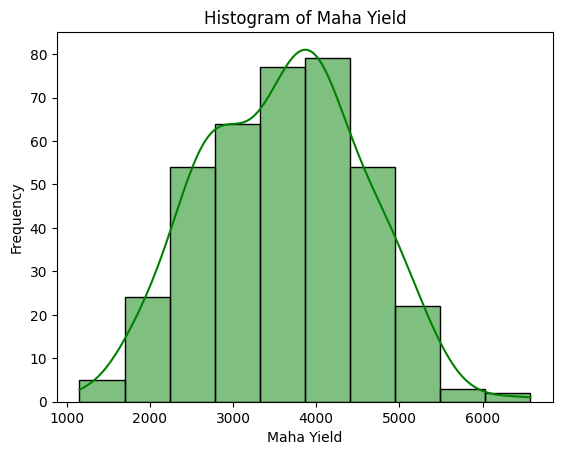

In [122]:
# Histogram of Maha yield
sns.histplot(maha_yield['Yield'], kde=True, bins=10, color='green')
plt.title('Histogram of Maha Yield')
plt.xlabel('Maha Yield')
plt.ylabel('Frequency')
plt.show()



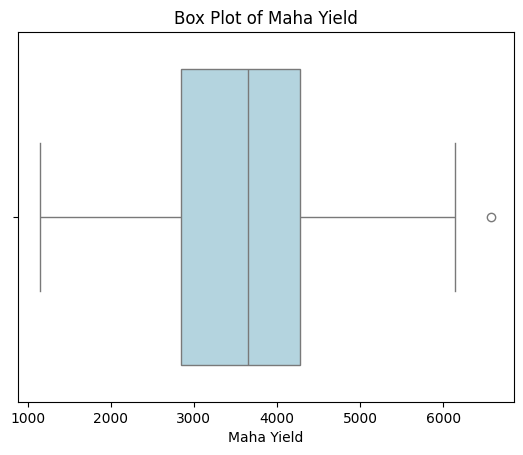

In [123]:
# Box Plot of Maha Yield
sns.boxplot(x=maha_yield['Yield'], color='lightblue')
plt.title('Box Plot of Maha Yield')
plt.xlabel('Maha Yield')
plt.show()

In [124]:
import pandas as pd
import numpy as np

# Calculate the IQR (Interquartile Range)
Q1 = maha_yield['Yield'].quantile(0.25)
Q3 = maha_yield['Yield'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find rows where Yield is an outlier
outliers = maha_yield[(maha_yield['Yield'] < lower_bound) | (maha_yield['Yield'] > upper_bound)]

# Print the outlier rows
display(outliers)


,District,Year,Yield,Cultivation_Season
359,HAMBANTOTA,2013,6575,2012-2013


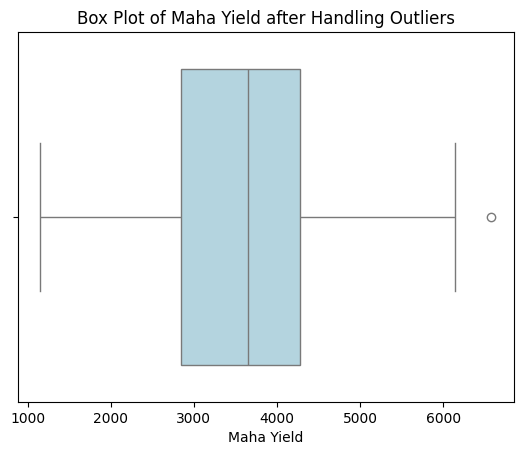

In [125]:
# Box Plot of Maha Yield
sns.boxplot(x=maha_yield['Yield'], color='lightblue')
plt.title('Box Plot of Maha Yield after Handling Outliers')
plt.xlabel('Maha Yield')
plt.show()

## Preprocessing Weather Dataset

In [353]:
file_path = '/content/drive/MyDrive/NEW_monthly_weather_data.csv'

# Load the dataset
weather_data = pd.read_csv(file_path)
weather_data.head()


,Year,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
0,1984,1,BATTICALOA,27.56,24.17,3.65,12.71,85.08,331.78,0.92
1,1984,1,JAFFNA,27.17,23.67,5.03,13.10,84.14,192.61,0.97
2,1984,1,MANNAR,27.97,22.03,4.17,14.18,87.13,254.00,0.98
3,1984,1,MONARAGALA,27.58,18.59,1.68,13.96,92.02,279.90,0.89
4,1984,1,MULLATIVU,26.89,23.68,4.65,13.10,84.98,266.93,0.97


### Handling Missing Values

In [354]:
# Select only numeric columns
numeric_columns = weather_data.select_dtypes(include=['number'])

# Check for missing values in numeric columns
missing_values_numeric = numeric_columns.isnull().sum()
print("Missing Values:\n", missing_values_numeric, "\n")

# Check for negative values in numeric columns
negative_values_numeric = (numeric_columns < 0).sum()
print("Negative Values:\n", negative_values_numeric)


Missing Values:
 Year     0
Month    0
Tmax     0
Tmin     0
Wind     0
SRAD     0
RH       0
Rain     0
Soil     0
dtype: int64 

Negative Values:
 Year     0
Month    0
Tmax     0
Tmin     0
Wind     0
SRAD     0
RH       0
Rain     0
Soil     0
dtype: int64


### Determine Relevant Months for Maha Season

The Maha season in Sri Lanka spans from **September to March** in the following year, roughly covering **Standard Meteorological Weeks (SMWs) 36 to 13**, which crosses over two calendar years. This aligns with the North-East Monsoon and represents one of the two main paddy cultivation seasons in Sri Lanka, as defined by the *Department of Census and Statistics in Sri Lanka*.

### Filter Data for the Maha Season

In [355]:
# Define Maha season months
maha_months_full = [8, 9, 10, 11, 12]

maha_season_data = weather_data[
    (
        ((weather_data['Month'].isin([8, 9, 10, 11, 12])) & (weather_data['Year'] == 1984)) |
        #((weather_data['Month'].isin([1])) & (weather_data['Year'] == 2015)) |
        ((weather_data['Month'].isin(maha_months_full)) & (weather_data['Year'] > 1984) & (weather_data['Year'] < 2015))
    )
]

# Display the filtered dataset
display(maha_season_data)


,Year,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
84,1984,8,BATTICALOA,32.13,25.16,3.21,19.53,72.28,53.23,0.59
85,1984,8,JAFFNA,30.79,26.21,5.58,21.48,76.33,23.38,0.57
86,1984,8,MANNAR,31.07,25.38,5.20,21.30,78.19,14.91,0.57
87,1984,8,MONARAGALA,33.08,19.69,2.99,19.79,72.44,38.25,0.61
88,1984,8,MULLATIVU,31.27,25.69,5.43,21.48,77.58,30.63,0.60
...,...,...,...,...,...,...,...,...,...,...
4459,2014,12,TRINCOMALEE,28.30,23.76,4.25,11.78,88.11,671.55,0.99
4460,2014,12,VAVUNIYA,28.73,22.89,3.34,11.07,90.79,505.92,0.98
4461,2014,12,HAMBANTOTA,28.72,24.89,3.36,13.51,86.73,707.49,0.95
4462,2014,12,AMPARA,28.30,24.69,3.73,10.78,87.59,866.01,0.99


In [356]:
maha_season_data = maha_season_data.copy()

In [357]:
# Assign Cultivation Season based on months
maha_season_data['Cultivation_Season'] = np.where(
    maha_season_data['Month'] >= 8,
    maha_season_data['Year'].astype(str) + '-' + (maha_season_data['Year'] + 1).astype(str),
    (maha_season_data['Year'] - 1).astype(str) + '-' + maha_season_data['Year'].astype(str)
)

cols = list(maha_season_data.columns)
cols.insert(1, cols.pop(cols.index('Cultivation_Season')))

# Apply new column order
maha_season_data = maha_season_data[cols]

# Display modified dataframe
display(maha_season_data.head(20))


,Year,Cultivation_Season,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
84,1984,1984-1985,8,BATTICALOA,32.13,25.16,3.21,19.53,72.28,53.23,0.59
85,1984,1984-1985,8,JAFFNA,30.79,26.21,5.58,21.48,76.33,23.38,0.57
86,1984,1984-1985,8,MANNAR,31.07,25.38,5.20,21.30,78.19,14.91,0.57
87,1984,1984-1985,8,MONARAGALA,33.08,19.69,2.99,19.79,72.44,38.25,0.61
88,1984,1984-1985,8,MULLATIVU,31.27,25.69,5.43,21.48,77.58,30.63,0.60
89,1984,1984-1985,8,POLONNARUWA,33.45,22.56,4.58,19.53,77.00,54.60,0.52
90,1984,1984-1985,8,PUTTALAM,30.67,23.83,5.09,21.30,83.33,15.56,0.61
91,1984,1984-1985,8,TRINCOMALEE,32.42,24.15,5.61,19.40,79.22,73.03,0.64
92,1984,1984-1985,8,VAVUNIYA,33.33,23.91,4.20,21.48,78.44,31.83,0.58
93,1984,1984-1985,8,HAMBANTOTA,29.04,24.43,6.09,19.79,84.41,45.28,0.67


## Merge Weather and Yield Data

In [358]:
maha_season_data = maha_season_data.drop(columns=['Year'])

# Merge the weather data with the yield data
merged_data = maha_season_data.merge(
    maha_yield,
    on=['District', 'Cultivation_Season'],
    how='inner'
)

display(merged_data.head(20))


,Cultivation_Season,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil,Year,Yield
0,1984-1985,8,BATTICALOA,32.13,25.16,3.21,19.53,72.28,53.23,0.59,1985,3163
1,1984-1985,8,JAFFNA,30.79,26.21,5.58,21.48,76.33,23.38,0.57,1985,1687
2,1984-1985,8,MANNAR,31.07,25.38,5.20,21.30,78.19,14.91,0.57,1985,3781
3,1984-1985,8,MONARAGALA,33.08,19.69,2.99,19.79,72.44,38.25,0.61,1985,2988
4,1984-1985,8,MULLATIVU,31.27,25.69,5.43,21.48,77.58,30.63,0.60,1985,2579
5,1984-1985,8,POLONNARUWA,33.45,22.56,4.58,19.53,77.00,54.60,0.52,1985,4874
6,1984-1985,8,PUTTALAM,30.67,23.83,5.09,21.30,83.33,15.56,0.61,1985,2643
7,1984-1985,8,TRINCOMALEE,32.42,24.15,5.61,19.40,79.22,73.03,0.64,1985,3379
8,1984-1985,8,VAVUNIYA,33.33,23.91,4.20,21.48,78.44,31.83,0.58,1985,2946
9,1984-1985,8,HAMBANTOTA,29.04,24.43,6.09,19.79,84.41,45.28,0.67,1985,4328


In [359]:
# Weather variables and month names in seasonal order
weather_variables = ['Tmax', 'SRAD', 'RH', 'Rain']
month_names = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_name_map = dict(zip([8, 9, 10, 11, 12], month_names))


In [360]:
# Create a copy of the data
pivot_data = merged_data.copy()

# Extract the yield year from the Cultivation_Season
pivot_data['Year'] = pivot_data['Cultivation_Season'].apply(lambda x: int(x.split('-')[1]))

# Pivot to wide format with month-specific columns
pivot_data = pivot_data.pivot_table(
    index=['Cultivation_Season', 'District', 'Year', 'Yield'],
    columns='Month',
    values=weather_variables,
    aggfunc='first'
)

# Flatten MultiIndex columns
pivot_data.columns = [f"{month_name_map[month]}_{var}" for var, month in pivot_data.columns]

# Reset index to keep 'Year' as a regular column
pivot_data = pivot_data.reset_index()

# Ensure the correct seasonal column order
ordered_columns = (
    ['Cultivation_Season', 'District', 'Year', 'Yield'] +
    [f"{month}_{var}" for month in month_names for var in weather_variables]
)

# Reorder the DataFrame columns
pivot_data = pivot_data[ordered_columns]

# Display the restructured DataFrame
display(pivot_data.head(20))


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,...,Oct_RH,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain
0,1984-1985,AMPARA,1985,3827,32.13,19.53,72.28,53.23,33.00,19.81,...,76.50,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80
1,1984-1985,ANURADHAPURA,1985,3972,34.34,21.48,79.94,32.92,35.49,17.28,...,85.28,115.19,30.03,17.14,88.92,278.85,29.50,15.33,87.58,85.09
2,1984-1985,BATTICALOA,1985,3163,32.13,19.53,72.28,53.23,33.00,19.81,...,76.50,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80
3,1984-1985,HAMBANTOTA,1985,4328,29.04,19.79,84.41,45.28,29.40,19.80,...,83.41,209.60,28.33,17.65,81.97,327.30,28.24,16.66,82.28,49.10
4,1984-1985,JAFFNA,1985,1687,30.79,21.48,76.33,23.38,30.54,19.14,...,79.45,101.59,28.77,15.47,81.68,226.04,27.82,13.99,79.70,94.21
5,1984-1985,MANNAR,1985,3781,31.07,21.30,78.19,14.91,31.28,20.31,...,81.69,91.90,29.19,16.57,84.00,256.05,28.43,15.75,82.49,87.11
6,1984-1985,MONARAGALA,1985,2988,33.08,19.79,72.44,38.25,34.37,19.80,...,80.14,199.65,28.56,17.65,88.76,237.55,29.15,16.66,88.40,52.62
7,1984-1985,MULLATIVU,1985,2579,31.27,21.48,77.58,30.63,31.51,19.14,...,80.73,103.23,28.90,15.47,82.82,262.20,27.69,13.99,80.46,104.56
8,1984-1985,POLONNARUWA,1985,4874,33.45,19.53,77.00,54.60,35.05,19.81,...,83.97,113.58,30.11,16.61,86.68,303.79,29.84,15.23,85.72,95.29
9,1984-1985,PUTTALAM,1985,2643,30.67,21.30,83.33,15.56,31.54,20.31,...,82.81,146.78,29.74,16.57,85.44,286.65,29.67,15.75,84.33,53.05


### Handling outliers

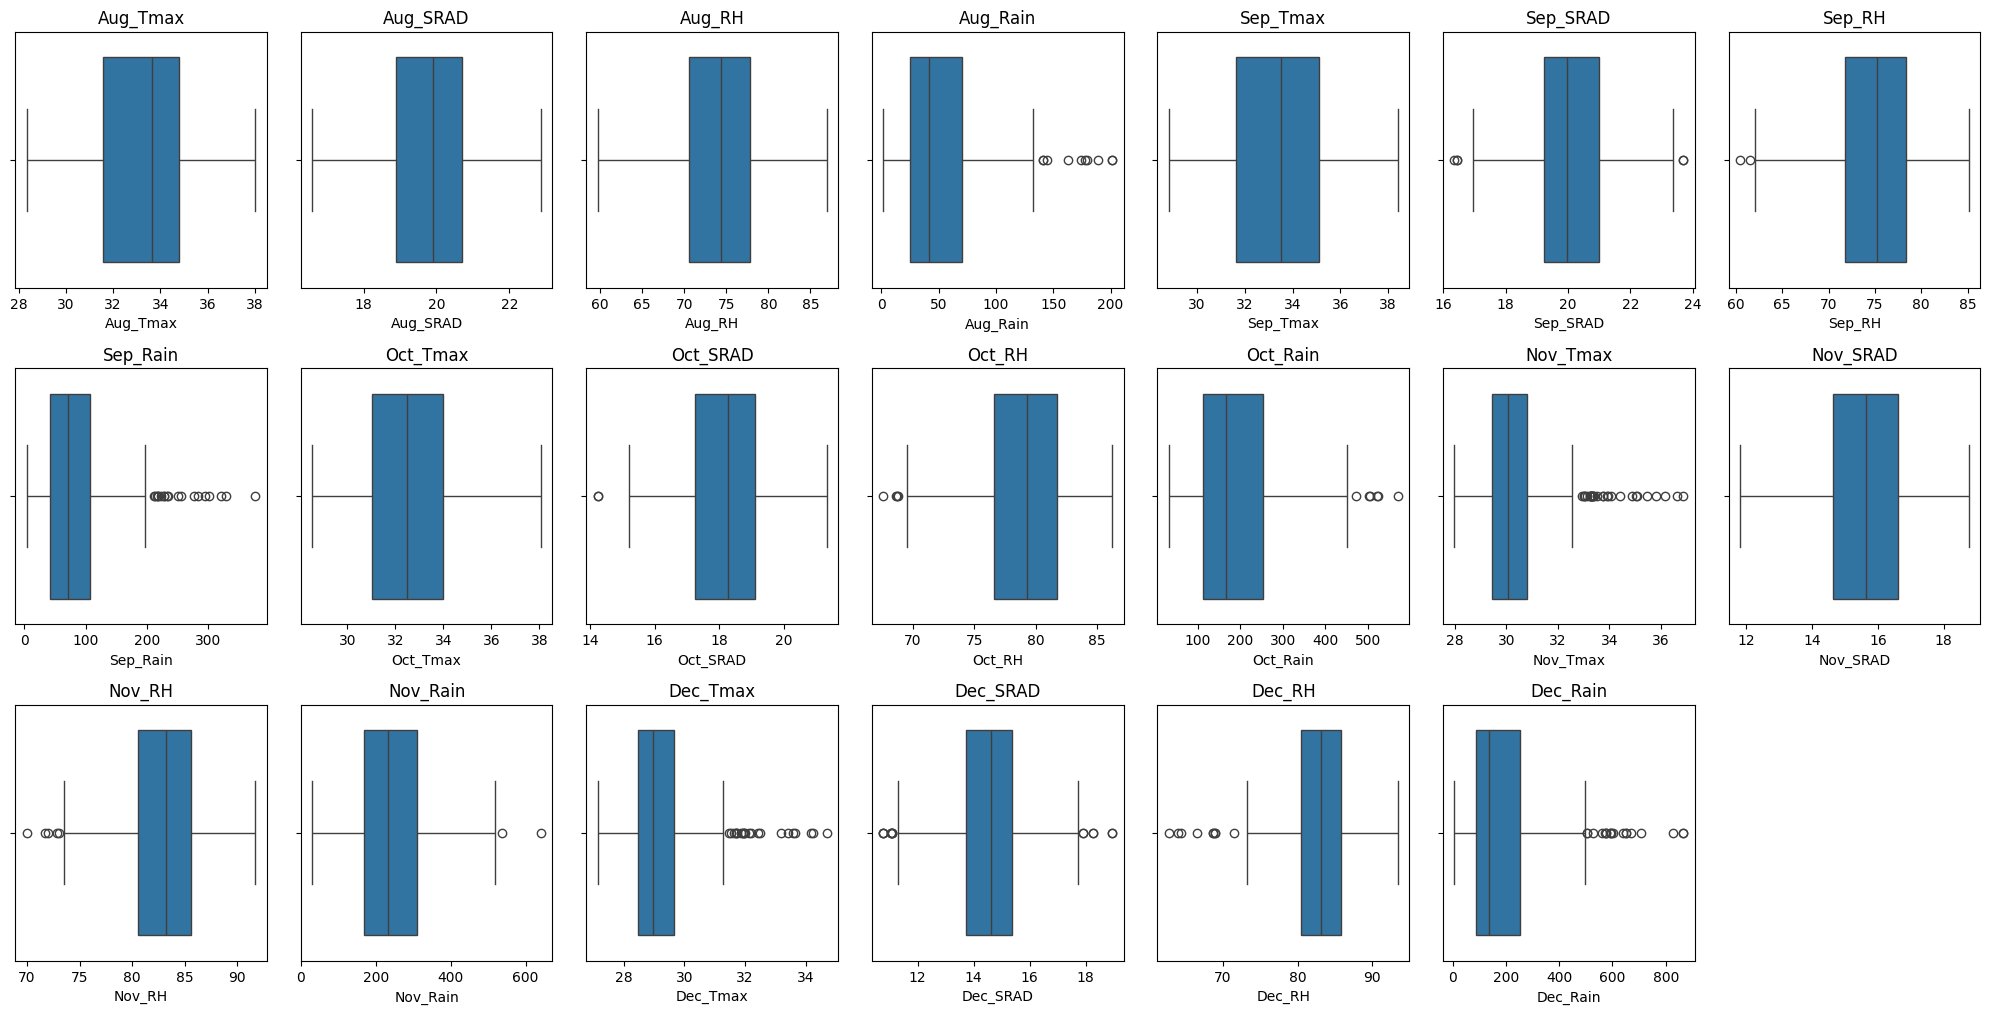

In [361]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Generate horizontal box plots for each weather variable
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 7, i)
    sns.boxplot(x=pivot_data[variable])
    plt.title(f'{variable}')
    plt.xlabel(variable)

plt.tight_layout()
plt.show()


In [392]:
import numpy as np

# Function for handling outliers (capping) with in-place updates
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Update the DataFrame column with capped values directly
    df[column] = np.clip(df[column], lower_bound, upper_bound)


In [393]:
# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Apply outlier capping to all weather variables
for variable in weather_columns:
    cap_outliers(pivot_data, variable)


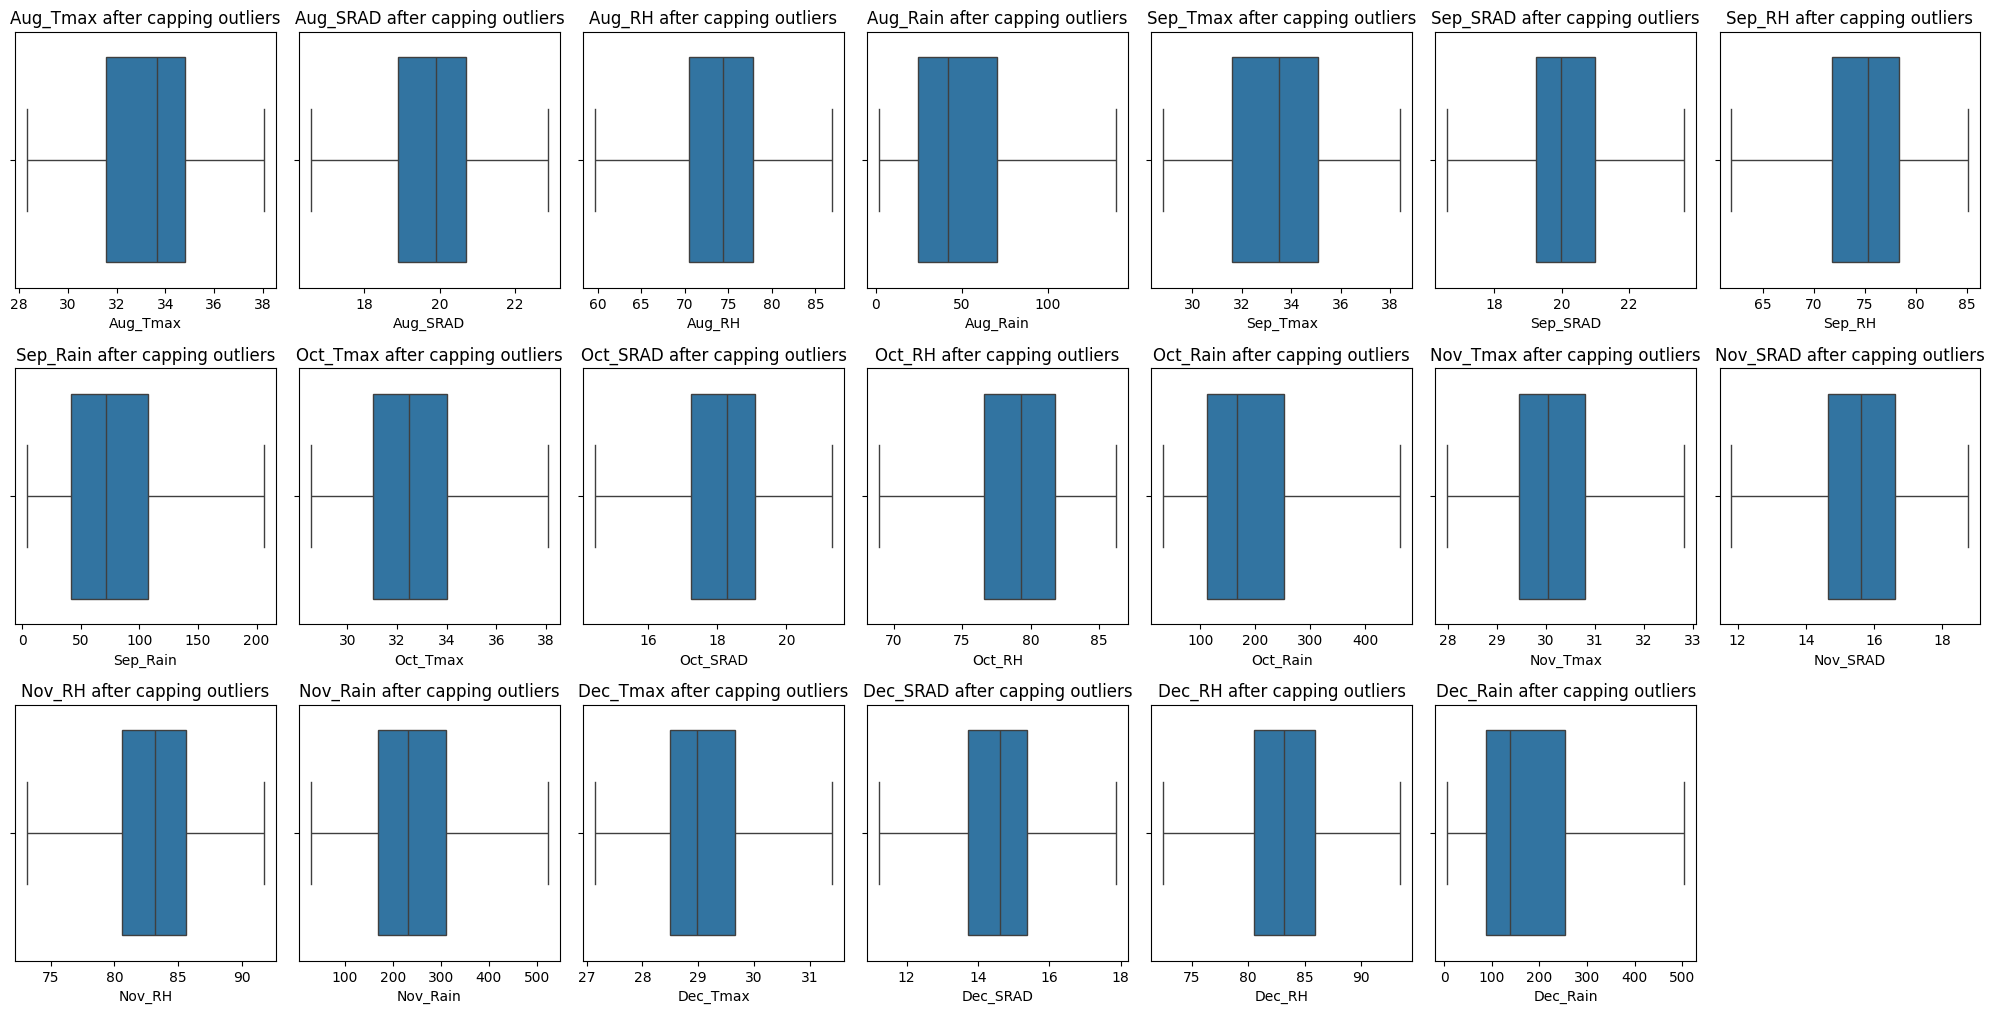

In [394]:
# Generate horizontal box plots for each weather variable after capping outliers
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 7, i)
    sns.boxplot(x=pivot_data[variable])
    plt.title(f'{variable} after capping outliers')
    plt.xlabel(variable)

plt.tight_layout()
plt.show()

### Correlation of Weather Variables with Final Yield

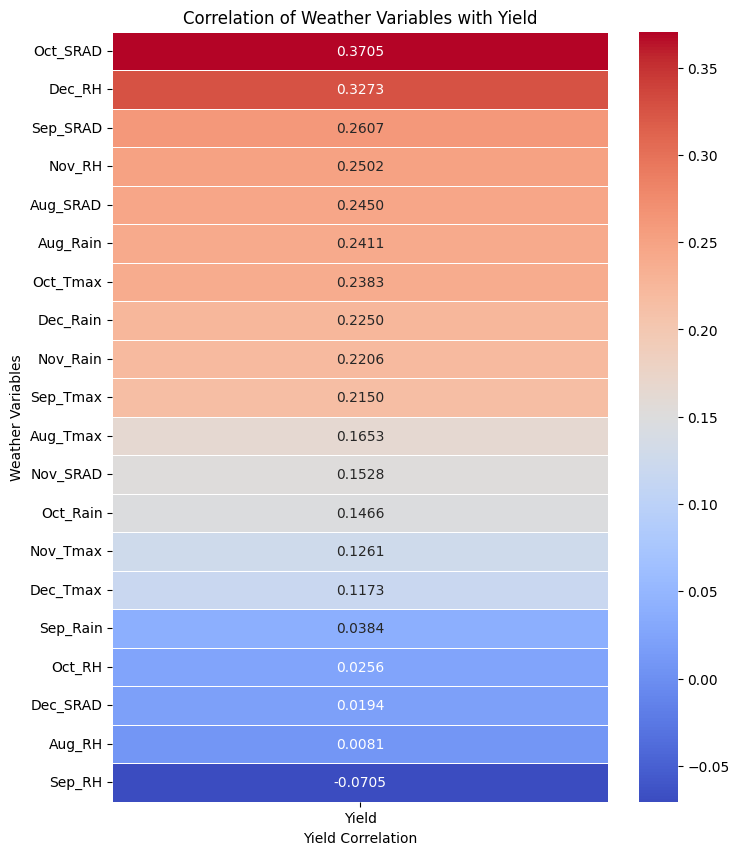

In [395]:
# Calculate the correlation of all weather variables with Yield
correlation_df = pivot_data[weather_columns + ['Yield']].corr()['Yield'].drop('Yield').sort_values(ascending=False)

# Convert to DataFrame for heatmap
correlation_matrix = correlation_df.to_frame()

# Plot the heatmap
plt.figure(figsize=(8, len(correlation_df) * 0.5))  # Adjust size based on number of variables
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, cbar=True)

# Titles and labels
plt.title("Correlation of Weather Variables with Yield")
plt.xlabel("Yield Correlation")
plt.ylabel("Weather Variables")

# Show the plot
plt.show()

In [396]:
# Select all weather variables excluding non-numeric columns
weather_cols = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]
num = int(len(weather_cols) / 6)


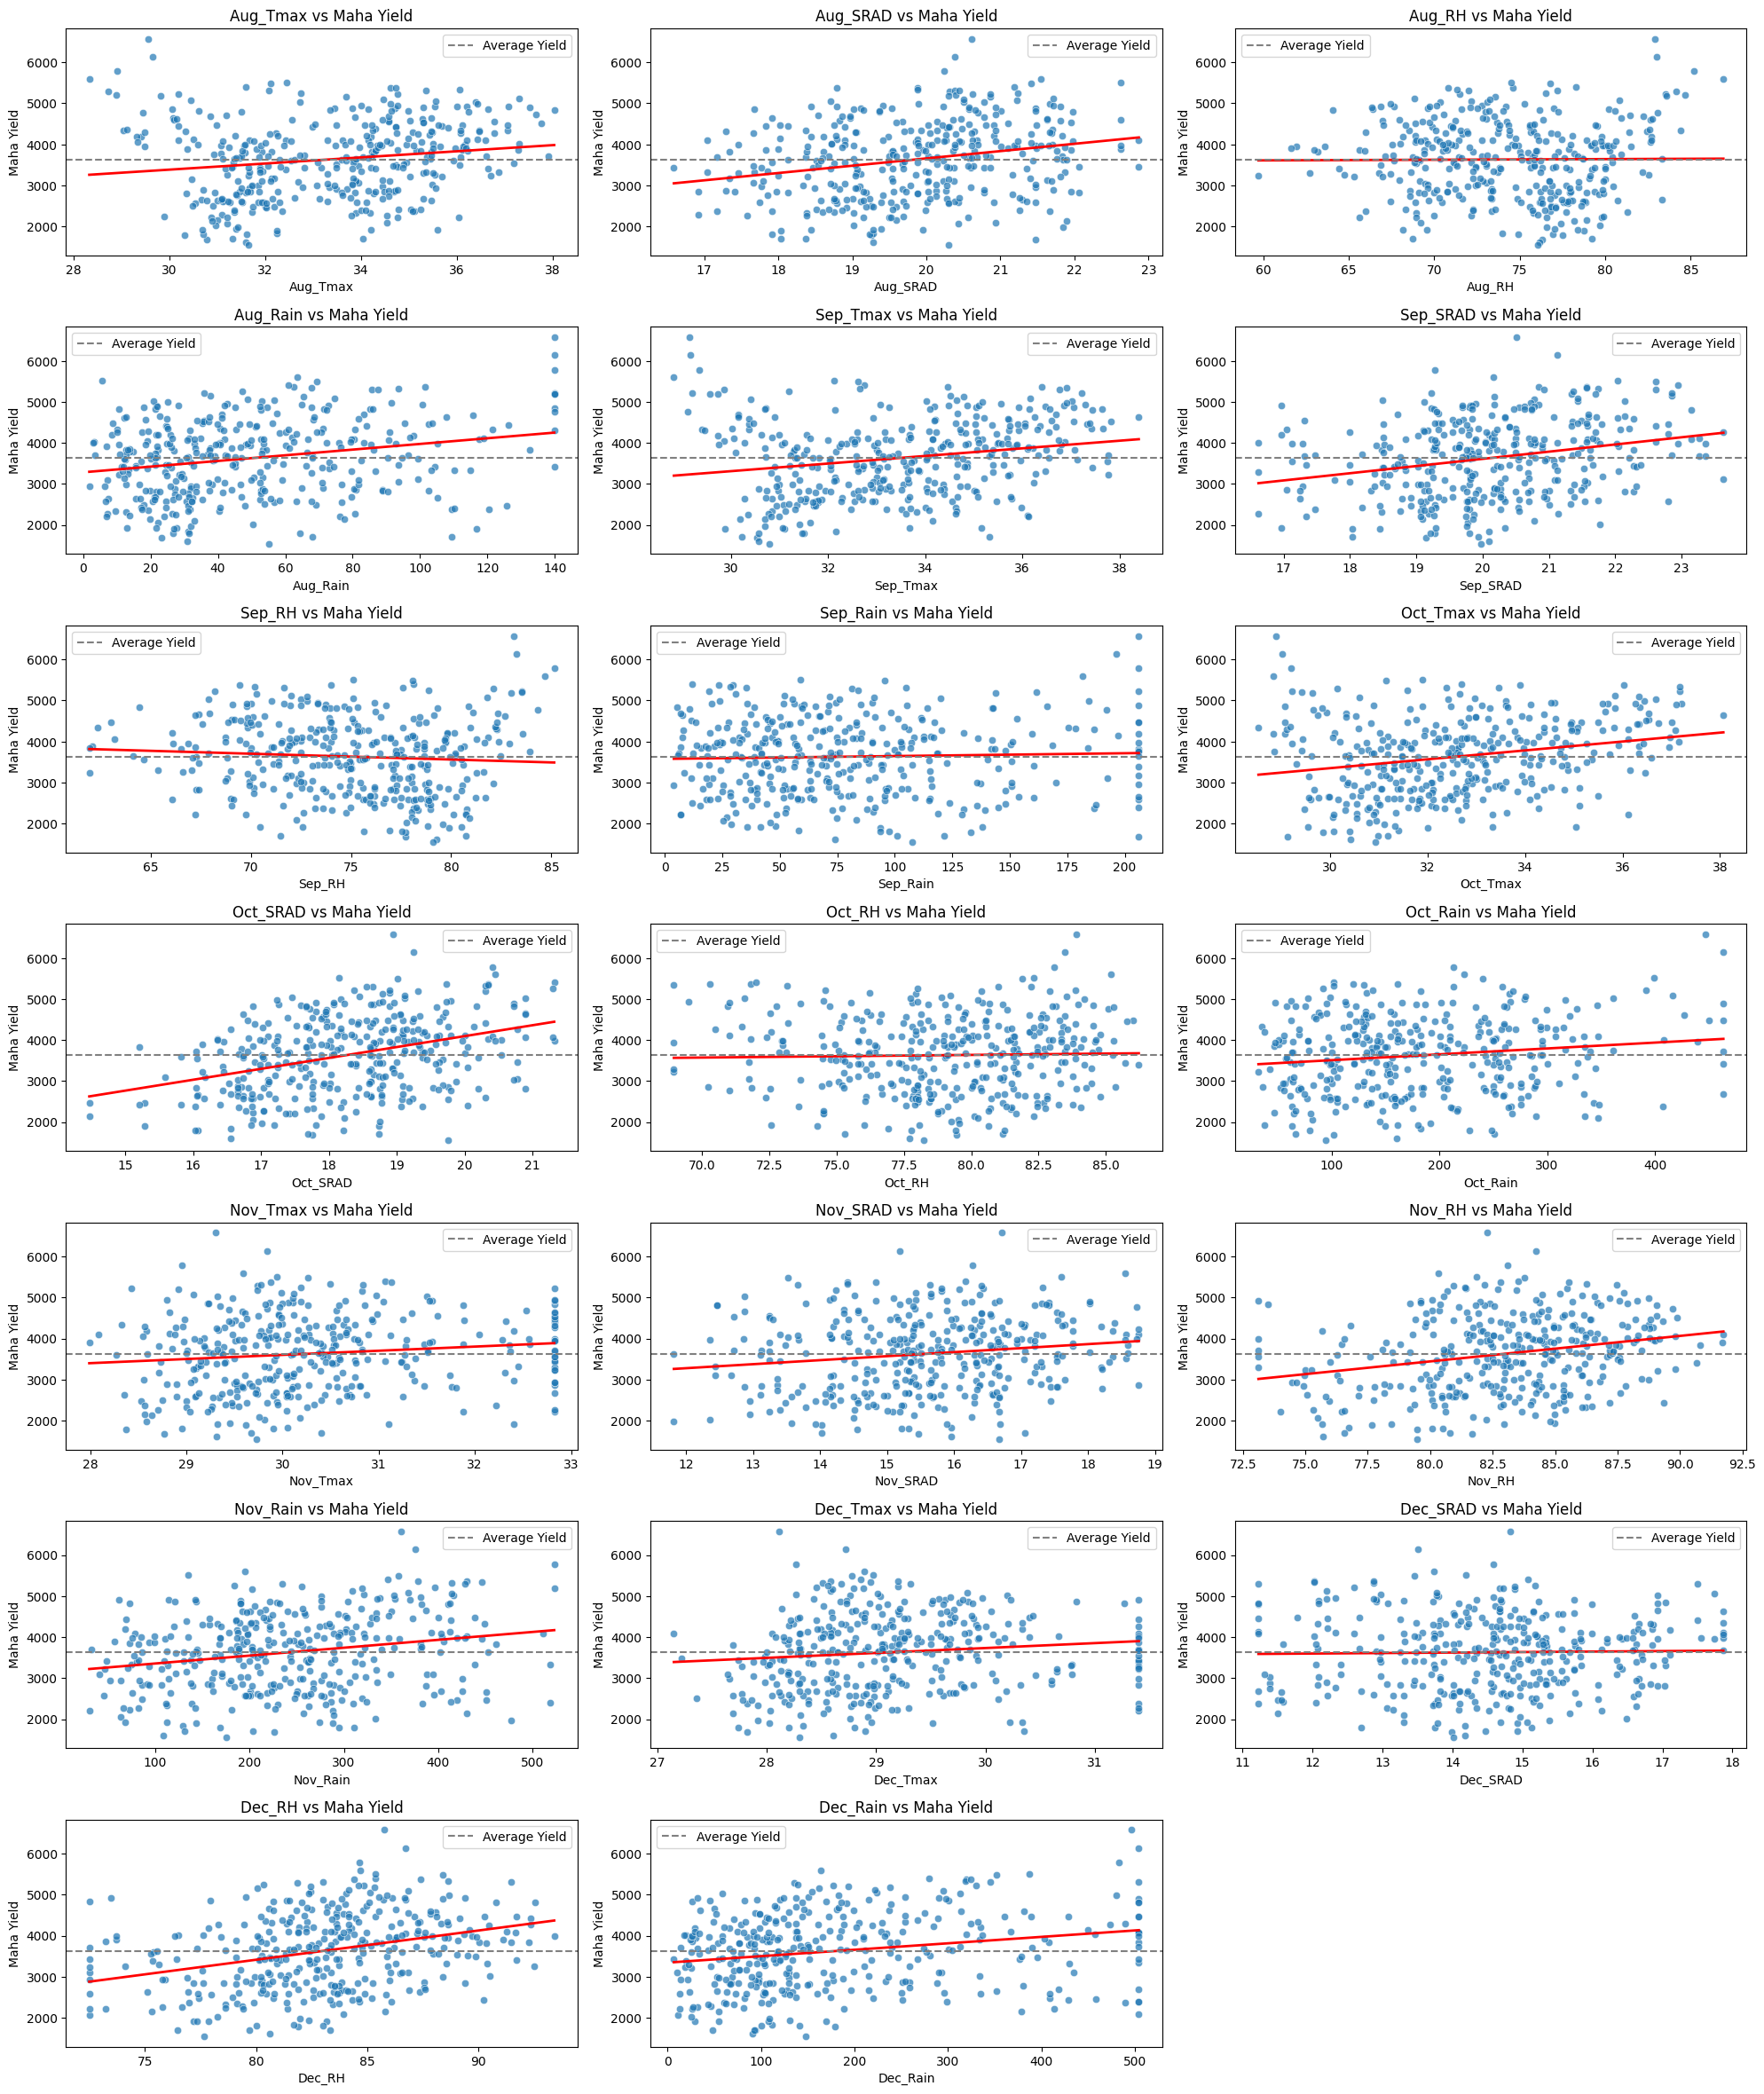

In [397]:
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_cols, start=1):
    plt.subplot(9, num, i)
    sns.scatterplot(x=pivot_data[variable], y=pivot_data['Yield'], alpha=0.7)
    sns.regplot(x=pivot_data[variable], y=pivot_data['Yield'], scatter=False, ci=None, color='red', line_kws={"linewidth": 2})
    plt.title(f'{variable} vs Maha Yield')
    plt.xlabel(variable)
    plt.ylabel('Maha Yield')
    plt.axhline(y=pivot_data['Yield'].mean(), color='gray', linestyle='--', label='Average Yield')
    plt.legend()

plt.tight_layout()
plt.show()

In [398]:
# Ensure the final dataframe includes the selected features + Yield
final_df = pivot_data[weather_cols + ['Yield']].copy()

# Display the final DataFrame
display(final_df.head())


,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,...,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain,Yield
0,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,3827
1,34.34,21.48,79.94,32.92,35.49,17.28,78.64,206.12875,30.75,18.02,...,115.19,30.03,17.14,88.92,278.85,29.50,15.33,87.58,85.09,3972
2,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,3163
3,29.04,19.79,84.41,45.28,29.40,19.80,80.97,175.33000,28.53,18.61,...,209.60,28.33,17.65,81.97,327.30,28.24,16.66,82.28,49.10,4328
4,30.79,21.48,76.33,23.38,30.54,19.14,77.73,206.12875,29.12,17.76,...,101.59,28.77,15.47,81.68,226.04,27.82,13.99,79.70,94.21,1687


In [399]:
from scipy.stats import skew

# Calculate skewness
skewness = skew(final_df['Yield'])

# Print result with interpretation
print(f"Skewness: {skewness:.4f}")

# Interpretation
if -0.5 <= skewness <= 0.5:
    print("The data is fairly symmetric (close to normal).")
elif -1 <= skewness < -0.5 or 0.5 < skewness <= 1:
    print("The data is moderately skewed.")
else:
    print("The data is highly skewed.")

Skewness: 0.0556
The data is fairly symmetric (close to normal).


In [400]:
# Determine min and max for equal-width binning
min_yield = final_df['Yield'].min()
max_yield = final_df['Yield'].max()

# Create equal-width bins
bins = np.linspace(min_yield, max_yield, num=4)

# Assign labels based on bin ranges
final_df['Yield_Class'] = pd.cut(final_df['Yield'], bins=bins, labels=['Low', 'Medium', 'High'], include_lowest=True)


In [401]:
# Print bin edges
print("\nYield Class Ranges:")
for i in range(len(bins) - 1):
    print(f"Class {i+1} ({['Low', 'Medium', 'High'][i]}): {bins[i]:.2f} to {bins[i+1]:.2f}")


Yield Class Ranges:
Class 1 (Low): 1547.00 to 3223.00
Class 2 (Medium): 3223.00 to 4899.00
Class 3 (High): 4899.00 to 6575.00


In [402]:
display(final_df.head())

,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,...,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain,Yield,Yield_Class
0,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,3827,Medium
1,34.34,21.48,79.94,32.92,35.49,17.28,78.64,206.12875,30.75,18.02,...,30.03,17.14,88.92,278.85,29.50,15.33,87.58,85.09,3972,Medium
2,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,3163,Low
3,29.04,19.79,84.41,45.28,29.40,19.80,80.97,175.33000,28.53,18.61,...,28.33,17.65,81.97,327.30,28.24,16.66,82.28,49.10,4328,Medium
4,30.79,21.48,76.33,23.38,30.54,19.14,77.73,206.12875,29.12,17.76,...,28.77,15.47,81.68,226.04,27.82,13.99,79.70,94.21,1687,Low


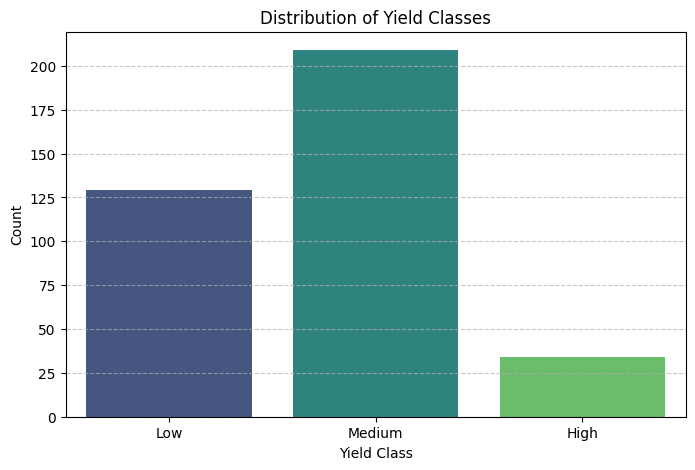

In [403]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot for class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Yield_Class', hue='Yield_Class', data=final_df, palette='viridis')

# Add labels
plt.title('Distribution of Yield Classes')
plt.xlabel('Yield Class')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


In [404]:
# Drop the 'Yield' column from the final DataFrame
final_df = final_df.drop(columns=['Yield'])

# Display the updated DataFrame
display(final_df.head())


,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,...,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain,Yield_Class
0,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,Medium
1,34.34,21.48,79.94,32.92,35.49,17.28,78.64,206.12875,30.75,18.02,...,115.19,30.03,17.14,88.92,278.85,29.50,15.33,87.58,85.09,Medium
2,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,Low
3,29.04,19.79,84.41,45.28,29.40,19.80,80.97,175.33000,28.53,18.61,...,209.60,28.33,17.65,81.97,327.30,28.24,16.66,82.28,49.10,Medium
4,30.79,21.48,76.33,23.38,30.54,19.14,77.73,206.12875,29.12,17.76,...,101.59,28.77,15.47,81.68,226.04,27.82,13.99,79.70,94.21,Low


In [405]:
final_df.to_csv('/content/FINAL_yield_pred_data.csv', index=False)

## Split Data into Train-Test Sets

In [406]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [407]:
# Load dataset
df = pd.read_csv('/content/FINAL_yield_pred_data.csv')

# Perform 80-20 random train-test split
X = df.drop(columns=["Yield_Class"])  # Features
y = df["Yield_Class"]  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Print dataset sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 297
Testing samples: 75


In [408]:
display(X_train.head())

,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain
206,34.44,21.63,67.95,12.31,35.22,20.33,70.13,91.50,32.98,19.05,76.24,89.84,31.34,16.41,79.84,211.35,28.59,15.15,81.81,199.18
259,32.30,21.85,75.10,46.96,31.81,19.76,77.65,33.02,31.80,17.01,79.13,197.25,29.38,11.82,84.63,453.06,28.00,15.38,82.41,118.70
42,36.88,17.67,68.63,86.72,36.48,19.22,70.61,102.35,31.62,17.59,84.46,287.89,29.12,17.31,86.90,192.95,29.33,17.04,88.56,87.37
157,36.78,20.05,70.65,17.56,36.54,19.54,74.12,65.42,37.09,16.55,78.19,179.19,30.48,14.75,88.92,221.79,30.00,14.56,88.65,188.68
52,31.31,18.04,79.22,109.45,30.22,18.04,80.71,121.40,30.99,18.74,75.31,66.19,29.67,14.03,76.55,131.35,30.35,14.93,76.47,48.34


In [409]:
# Count samples in each class for training and testing sets
train_class_counts = y_train.value_counts()
test_class_counts = y_test.value_counts()

# Print the class distribution
print("Training Set Class Distribution:\n", train_class_counts)
print("\nTesting Set Class Distribution:\n", test_class_counts)

Training Set Class Distribution:
 Yield_Class
Medium    167
Low       103
High       27
Name: count, dtype: int64

Testing Set Class Distribution:
 Yield_Class
Medium    42
Low       26
High       7
Name: count, dtype: int64


In [410]:
# Convert counts to percentages
train_class_percentages = (train_class_counts / len(y_train)) * 100
test_class_percentages = (test_class_counts / len(y_test)) * 100

# Print the class distribution percentages
print("\nTraining Set Class Distribution Percentages:\n", train_class_percentages)


Training Set Class Distribution Percentages:
 Yield_Class
Medium    56.228956
Low       34.680135
High       9.090909
Name: count, dtype: float64


In [411]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Balanced Training Set Class Distribution:\n", y_train_smote.value_counts())

Balanced Training Set Class Distribution:
 Yield_Class
Low       167
Medium    167
High      167
Name: count, dtype: int64


### Scale Data

In [412]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [413]:
# Convert the scaled array back to a DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Display the first few rows
display(X_train_scaled_df.head())

,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain
0,0.725896,1.437944,-1.552900,-1.294431,1.021315,0.062494,-1.311697,0.074379,0.284348,0.449957,-0.733330,-1.013914,1.022858,0.627211,-0.837914,-0.460881,-0.573679,0.557569,-0.299577,0.001117
1,-0.322382,1.620813,-0.040599,-0.320041,-0.598403,-0.357209,0.400645,-1.001355,-0.306619,-1.122544,0.050251,0.034579,-0.768220,-2.742926,0.560668,1.756840,-1.273475,0.726670,-0.147630,-0.609936
2,1.921128,-1.853698,-1.409073,0.798047,1.619803,-0.754823,-1.202398,0.273964,-0.396766,-0.675461,1.495401,0.919371,-1.005812,1.288022,1.223461,-0.629704,0.304030,1.947133,1.409828,-0.847813
3,1.872143,0.124612,-0.981821,-1.146797,1.648303,-0.519200,-0.403154,-0.405360,2.342714,-1.477128,-0.204616,-0.141715,0.236977,-0.591619,1.813260,-0.365093,1.098713,0.123790,1.432620,-0.078605
4,-0.807333,-1.546145,0.830824,1.437236,-1.353638,-1.623681,1.097422,0.624387,-0.712282,0.210998,-0.985486,-1.244775,-0.503214,-1.120268,-1.798527,-1.194892,1.513846,0.395821,-1.651906,-1.144152


In [414]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train_smote)



RandomForestClassifier(random_state=42)

In [415]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Predict on training and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Compute accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Print results
    print(f"\n{type(model).__name__} Training Accuracy: {train_accuracy:.4f}")
    print("\nClassification Report (Training Data):")
    print(classification_report(y_train, y_train_pred))

    print(f"\n{type(model).__name__} Test Accuracy: {test_accuracy:.4f}")
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))


In [416]:
# Evaluate the model
evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train_smote, y_test)



RandomForestClassifier Training Accuracy: 0.9641

Classification Report (Training Data):
              precision    recall  f1-score   support

        High       0.98      1.00      0.99       167
         Low       0.96      0.94      0.95       167
      Medium       0.95      0.95      0.95       167

    accuracy                           0.96       501
   macro avg       0.96      0.96      0.96       501
weighted avg       0.96      0.96      0.96       501


RandomForestClassifier Test Accuracy: 0.6267

Classification Report (Test Data):
              precision    recall  f1-score   support

        High       0.40      0.29      0.33         7
         Low       0.65      0.50      0.57        26
      Medium       0.64      0.76      0.70        42

    accuracy                           0.63        75
   macro avg       0.56      0.52      0.53        75
weighted avg       0.62      0.63      0.62        75



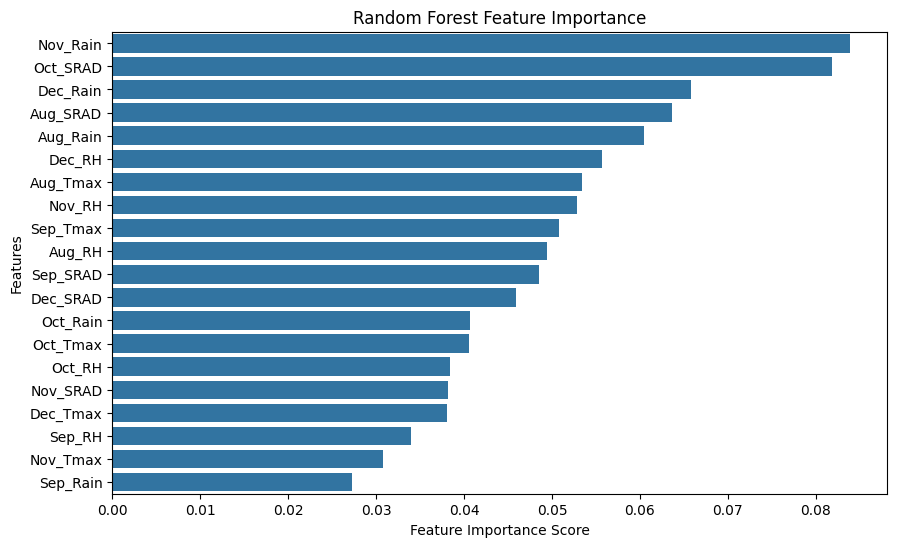

In [417]:
# Get feature importance scores
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train_scaled_df.columns)

# Sort and plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.sort_values(ascending=False), y=feature_importance.sort_values(ascending=False).index)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()


RandomForestClassifier Training Accuracy: 0.9641

Classification Report (Training Data):
              precision    recall  f1-score   support

        High       0.98      1.00      0.99       167
         Low       0.96      0.94      0.95       167
      Medium       0.95      0.95      0.95       167

    accuracy                           0.96       501
   macro avg       0.96      0.96      0.96       501
weighted avg       0.96      0.96      0.96       501


RandomForestClassifier Test Accuracy: 0.6267

Classification Report (Test Data):
              precision    recall  f1-score   support

        High       0.40      0.29      0.33         7
         Low       0.65      0.50      0.57        26
      Medium       0.64      0.76      0.70        42

    accuracy                           0.63        75
   macro avg       0.56      0.52      0.53        75
weighted avg       0.62      0.63      0.62        75

Initial Accuracy: 0.6267
Removing Sep_Rain -> New Accuracy: 0.6267

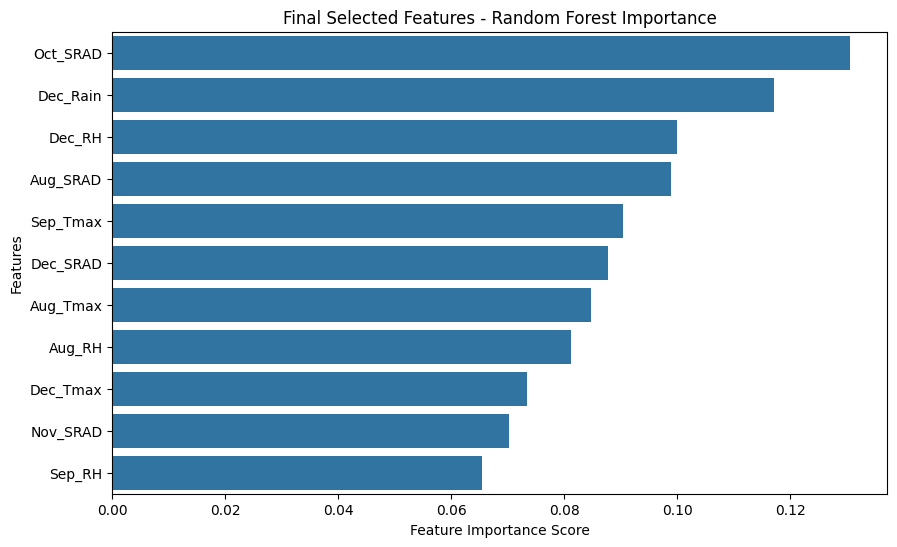

In [418]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Convert X_train_scaled back to a DataFrame (if needed)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Train initial Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train_smote)

# Evaluate initial model performance
evaluate_model(model, X_train_scaled, X_test_scaled, y_train_smote, y_test)

# Get feature importance
feature_importance = pd.Series(model.feature_importances_, index=X_train_scaled_df.columns)
feature_importance = feature_importance.sort_values(ascending=True)  # Start removing least important features

# Baseline accuracy with all features
y_pred = model.predict(X_test_scaled)
baseline_acc = accuracy_score(y_test, y_pred)
print(f"Initial Accuracy: {baseline_acc:.4f}")

removed_features = []
X_train_selected = X_train_scaled_df.copy()
X_test_selected = pd.DataFrame(X_test_scaled, columns=X_train.columns)  # Ensure test set matches feature selection

# Recursive Feature Removal Process
for feature in feature_importance.index:  # Start from the least important
    X_train_temp = X_train_selected.drop(columns=[feature])
    X_test_temp = X_test_selected.drop(columns=[feature])

    # Train model and check accuracy
    model.fit(X_train_temp, y_train_smote)
    y_pred_temp = model.predict(X_test_temp)
    new_acc = accuracy_score(y_test, y_pred_temp)

    print(f"Removing {feature} -> New Accuracy: {new_acc:.4f}")

    # Keep removing feature if accuracy does not drop
    if new_acc >= baseline_acc:
        X_train_selected = X_train_temp
        X_test_selected = X_test_temp
        baseline_acc = new_acc  # Update baseline accuracy
        removed_features.append(feature)
    else:
        print(f"Reverting {feature} because accuracy dropped!")

# Retrain the model on the final selected features
model.fit(X_train_selected, y_train_smote)

# Now evaluate the model after feature selection
evaluate_model(model, X_train_selected, X_test_selected, y_train_smote, y_test)

print("\nFinal Selected Features:", list(X_train_selected.columns))
print("Removed Features:", removed_features)

# Plot remaining feature importance
final_feature_importance = pd.Series(model.feature_importances_, index=X_train_selected.columns)
plt.figure(figsize=(10, 6))
sns.barplot(x=final_feature_importance.sort_values(ascending=False), y=final_feature_importance.sort_values(ascending=False).index)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Final Selected Features - Random Forest Importance")
plt.show()


New Baseline Accuracy: 0.6667
Removing Sep_RH -> New Accuracy: 0.6400
Reverting Sep_RH because accuracy dropped!
Removing Nov_SRAD -> New Accuracy: 0.6267
Reverting Nov_SRAD because accuracy dropped!
Removing Dec_Tmax -> New Accuracy: 0.6667
Removing Aug_RH -> New Accuracy: 0.6533
Reverting Aug_RH because accuracy dropped!
Removing Aug_Tmax -> New Accuracy: 0.6267
Reverting Aug_Tmax because accuracy dropped!
Removing Dec_SRAD -> New Accuracy: 0.6533
Reverting Dec_SRAD because accuracy dropped!
Removing Sep_Tmax -> New Accuracy: 0.6667
Removing Aug_SRAD -> New Accuracy: 0.6667
Removing Dec_RH -> New Accuracy: 0.5867
Reverting Dec_RH because accuracy dropped!
Removing Dec_Rain -> New Accuracy: 0.6267
Reverting Dec_Rain because accuracy dropped!
Removing Oct_SRAD -> New Accuracy: 0.5733
Reverting Oct_SRAD because accuracy dropped!

RandomForestClassifier Training Accuracy: 0.9641

Classification Report (Training Data):
              precision    recall  f1-score   support

        High   

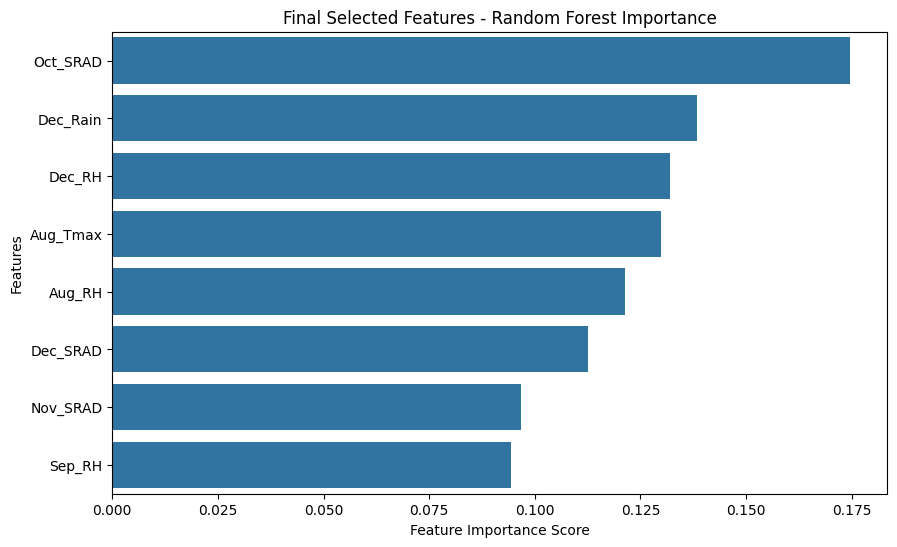

In [419]:
# Use the previously selected features for another round of feature selection
X_train_reselected = X_train_selected.copy()
X_test_reselected = X_test_selected.copy()

# Retrain the model and repeat feature selection
model.fit(X_train_reselected, y_train_smote)

# Get new feature importances
feature_importance_new = pd.Series(model.feature_importances_, index=X_train_reselected.columns).sort_values(ascending=True)

baseline_acc = accuracy_score(y_test, model.predict(X_test_reselected))
print(f"New Baseline Accuracy: {baseline_acc:.4f}")

removed_features_new = []

for feature in feature_importance_new.index:
    X_train_temp = X_train_reselected.drop(columns=[feature])
    X_test_temp = X_test_reselected.drop(columns=[feature])

    model.fit(X_train_temp, y_train_smote)
    new_acc = accuracy_score(y_test, model.predict(X_test_temp))

    print(f"Removing {feature} -> New Accuracy: {new_acc:.4f}")

    if new_acc >= baseline_acc:
        X_train_reselected = X_train_temp
        X_test_reselected = X_test_temp
        baseline_acc = new_acc
        removed_features_new.append(feature)
    else:
        print(f"Reverting {feature} because accuracy dropped!")

# Retrain the model on the final selected features
model.fit(X_train_reselected, y_train_smote)

# Now evaluate the model after feature selection
evaluate_model(model, X_train_reselected, X_test_reselected, y_train_smote, y_test)

# Final feature set after second selection round
print("\nFinal Selected Features After Second Round:", list(X_train_reselected.columns))
print("Newly Removed Features:", removed_features_new)


# Plot remaining feature importance
final_feature_importance = pd.Series(model.feature_importances_, index=X_train_reselected.columns)
plt.figure(figsize=(10, 6))
sns.barplot(x=final_feature_importance.sort_values(ascending=False), y=final_feature_importance.sort_values(ascending=False).index)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Final Selected Features - Random Forest Importance")
plt.show()


In [563]:
np.random.seed(50)
X_train_noisy = X_train_reselected + np.random.normal(0, 0.03, X_train_reselected.shape)


In [577]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


# param_grid = {
#     'n_estimators': [200, 250, 300],
#     'max_depth': [3, 5],
#     'min_samples_split': [15, 20],
#     'min_samples_leaf': [5, 10],
#     'max_features': ['log2']
# }

param_grid = {
    'n_estimators': [280],
    'max_depth': [8],
    'min_samples_split': [17],
    'min_samples_leaf': [8],
    'max_features': ['log2']
}





In [578]:
# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

# Perform grid search with 5-fold cross-validation
grid_search_rf = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_noisy, y_train_smote)

# Get the best parameters
best_rf_params = grid_search_rf.best_params_
print(f"\nBest Hyperparameters for Random Forest: {best_rf_params}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Hyperparameters for Random Forest: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 8, 'min_samples_split': 17, 'n_estimators': 280}


In [579]:
# Get the best model from GridSearch
best_rf_model = grid_search_rf.best_estimator_

# Train the best model
best_rf_model.fit(X_train_noisy, y_train_smote)

RandomForestClassifier(max_depth=8, max_features='log2', min_samples_leaf=8,
                       min_samples_split=17, n_estimators=280, random_state=42)

In [580]:
# Evaluate the optimized model
evaluate_model(best_rf_model, X_train_noisy, X_test_reselected, y_train_smote, y_test)



RandomForestClassifier Training Accuracy: 0.8263

Classification Report (Training Data):
              precision    recall  f1-score   support

        High       0.87      0.89      0.88       167
         Low       0.85      0.81      0.83       167
      Medium       0.76      0.78      0.77       167

    accuracy                           0.83       501
   macro avg       0.83      0.83      0.83       501
weighted avg       0.83      0.83      0.83       501


RandomForestClassifier Test Accuracy: 0.6133

Classification Report (Test Data):
              precision    recall  f1-score   support

        High       0.33      0.57      0.42         7
         Low       0.63      0.65      0.64        26
      Medium       0.69      0.60      0.64        42

    accuracy                           0.61        75
   macro avg       0.55      0.61      0.57        75
weighted avg       0.64      0.61      0.62        75



In [576]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(best_rf_model, X_train_noisy, y_train_smote, cv=5, scoring='accuracy')

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")



Cross-Validation Scores: [0.63366337 0.63       0.65       0.77       0.73      ]
Mean CV Accuracy: 0.6827
Standard Deviation: 0.0568
